# 📊 Superstore Sales Analysis

## End-to-End Data Analytics Project

### Project Objective

The objective of this project is to analyze Superstore sales data using Python, Pandas, and Matplotlib to identify sales trends, profitable products, customer behavior, and regional performance.

### Tools Used

- Python
- Pandas
- Matplotlib
- Jupyter Notebook

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv(
    r"C:\Users\kavita r yadav\OneDrive\Desktop\Data analyst portfolio\07_End_to_End_Ecommerce_Analytics\data\Superstore.csv",
    encoding="latin1"
)

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.shape

(9994, 21)

In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [9]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [13]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')

In [14]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed')

In [15]:
df[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [16]:
df['Order Year'] = df['Order Date'].dt.year

In [17]:
df['Order Month'] = df['Order Date'].dt.month

In [18]:
df['Order Month Name'] = df['Order Date'].dt.month_name()

In [19]:
df['Order Month Name'] = df['Order Date'].dt.month_name()

In [20]:
df[['Order Date', 'Order Year', 'Order Month', 'Order Month Name']].head()

,Order Date,Order Year,Order Month,Order Month Name
0,2016-11-08,2016,11,November
1,2016-11-08,2016,11,November
2,2016-06-12,2016,6,June
3,2015-10-11,2015,10,October
4,2015-10-11,2015,10,October


In [21]:
total_sales = df['Sales'].sum()
total_sales

np.float64(2297200.8603)

In [22]:
total_profit = df['Profit'].sum()
total_profit

np.float64(286397.0217)

In [23]:
total_orders = df['Order ID'].nunique()
total_orders

5009

In [24]:
total_customers = df['Customer ID'].nunique()
total_customers

793

In [25]:
average_order_value = total_sales / total_orders
average_order_value

np.float64(458.6146656618087)

In [5]:
df.groupby('Category')['Sales'].sum()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

In [8]:
sales_by_category = df.groupby('Category')['Sales'].sum()
sales_by_category

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

In [10]:
profit_by_category = df.groupby('Category')['Profit'].sum()
profit_by_category

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

In [11]:
sales_by_region = df.groupby('Region')['Sales'].sum()
sales_by_region

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

In [12]:
sales_by_region = df.groupby('Region')['Profit'].sum()
sales_by_region

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64

In [13]:
sales_by_segment = df.groupby('Segment')['Sales'].sum()
sales_by_segment

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

In [16]:
profit_by_segment =df.groupby('Segment')['Profit'].sum()
profit_by_segment

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64

In [18]:
sales_by_category.sort_values(ascending=False)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

In [19]:
sales_by_category.sort_values(ascending=False)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

In [8]:
top_products = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

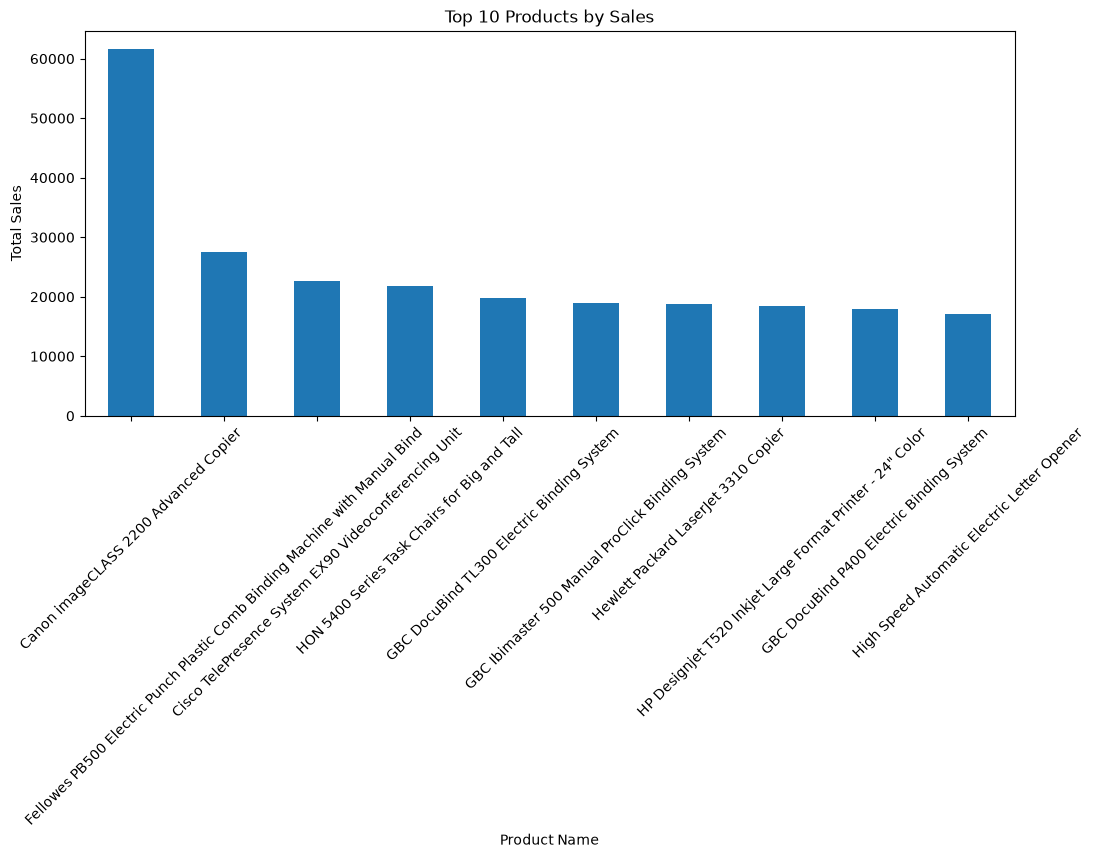

In [12]:
top_products.plot(kind='bar',figsize=(12,5))

plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.xticks(rotation = 45)
plt.tight_layout
plt.show()

In [15]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [21]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')

In [22]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed')

In [23]:
df[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [24]:
df['Order Year'] = df['Order Date'].dt.year

In [25]:
df['Order Month'] = df['Order Date'].dt.month

In [26]:
df[['Order Date', 'Order Year', 'Order Month']].head()

,Order Date,Order Year,Order Month
0,2016-11-08,2016,11
1,2016-11-08,2016,11
2,2016-06-12,2016,6
3,2015-10-11,2015,10
4,2015-10-11,2015,10


In [27]:
monthly_sales = df.groupby('Order Month')['Sales'].sum()
monthly_sales

Order Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64

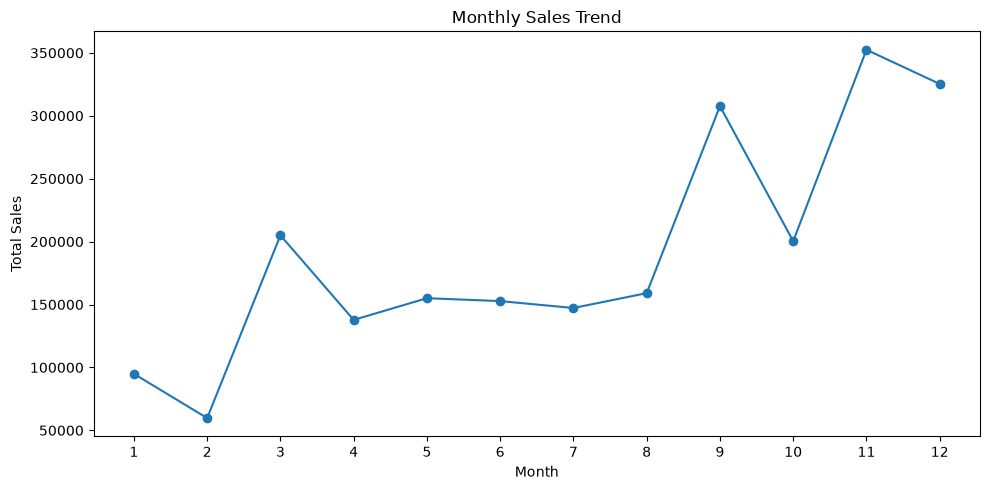

In [28]:
monthly_sales.plot(kind='line', marker='o', figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

In [29]:
yearly_sales = df.groupby('Order Year')['Sales'].sum()
yearly_sales

Order Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

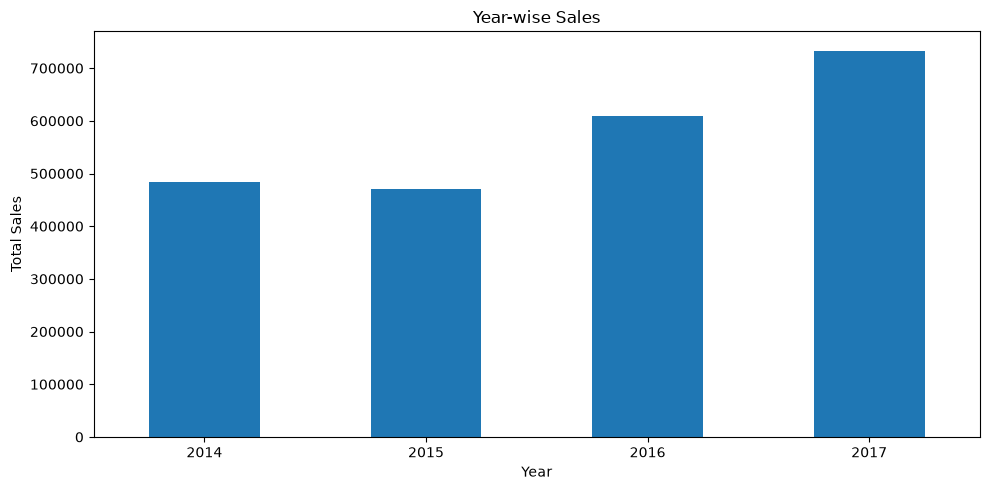

In [30]:
yearly_sales.plot(kind='bar', figsize=(10,5))

plt.title("Year-wise Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [32]:
category_performance = df.groupby('Category')[['Sales', 'Profit']].sum()
category_performance

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


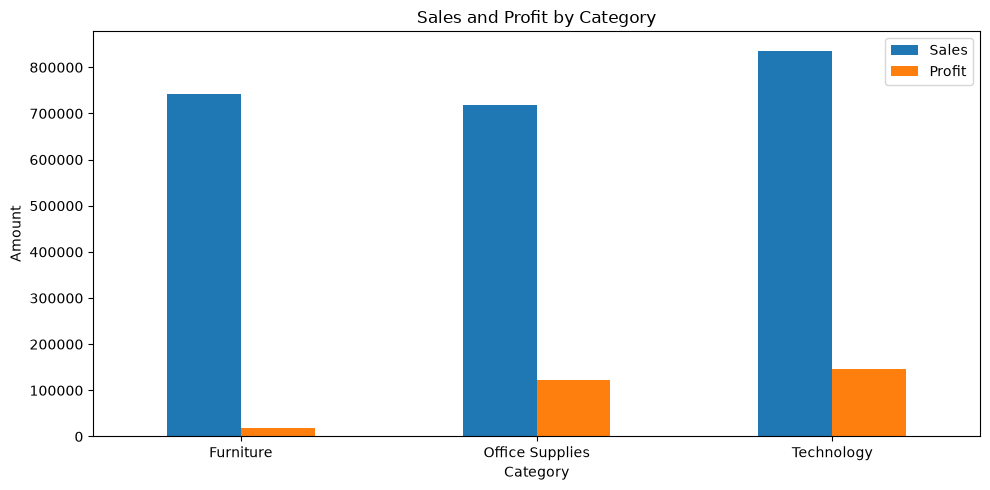

In [33]:
category_performance.plot(kind='bar', figsize=(10,5))

plt.title("Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [34]:
profit_by_subcategory = (
    df.groupby('Sub-Category')['Profit']
      .sum()
      .sort_values(ascending=False)
)

profit_by_subcategory

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

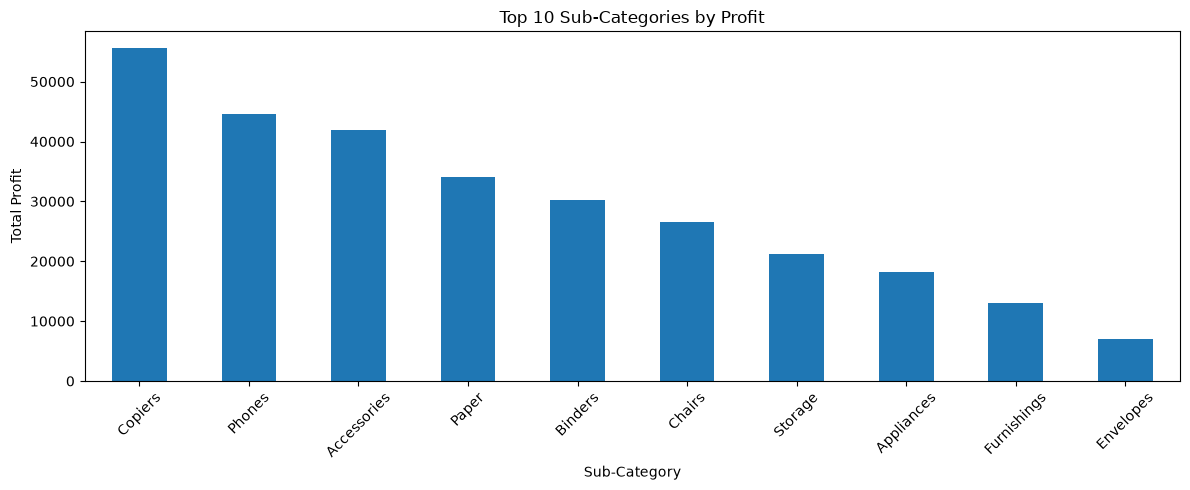

In [35]:
profit_by_subcategory.head(10).plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Top 10 Sub-Categories by Profit")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

In [38]:
profit_margin = (total_profit / total_sales) * 100
profit_margin

np.float64(12.467217240315605)

In [39]:
category_summary = df.groupby('Category')[['Sales', 'Profit']].sum()

category_summary['Profit Margin'] = (
    category_summary['Profit'] / category_summary['Sales']
) * 100

category_summary

,Sales,Profit,Profit Margin
Category,,,
Furniture,741999.7953,18451.2728,2.486695
Office Supplies,719047.0320,122490.8008,17.035158
Technology,836154.0330,145454.9481,17.395712


In [40]:
category_summary.sort_values(
    'Profit Margin',
    ascending=False
)

,Sales,Profit,Profit Margin
Category,,,
Technology,836154.0330,145454.9481,17.395712
Office Supplies,719047.0320,122490.8008,17.035158
Furniture,741999.7953,18451.2728,2.486695


In [41]:
discount_profit = df.groupby('Discount')['Profit'].sum()

discount_profit

Discount
0.00    320987.6032
0.10      9029.1770
0.15      1418.9915
0.20     90337.3060
0.30    -10369.2774
0.32     -2391.1377
0.40    -23057.0504
0.45     -2493.1111
0.50    -20506.4281
0.60     -5944.6552
0.70    -40075.3569
0.80    -30539.0392
Name: Profit, dtype: float64

In [42]:
discount_analysis = df.groupby('Discount')[['Sales', 'Profit']].sum()
discount_analysis

,Sales,Profit
Discount,,
0.00,1.087908e+06,320987.6032
0.10,5.436935e+04,9029.1770
0.15,2.755852e+04,1418.9915
0.20,7.645944e+05,90337.3060
0.30,1.032267e+05,-10369.2774
0.32,1.449346e+04,-2391.1377
0.40,1.164178e+05,-23057.0504
0.45,5.484974e+03,-2493.1111
0.50,5.891854e+04,-20506.4281


In [43]:
discount_analysis['Profit Margin'] = (
    discount_analysis['Profit'] / discount_analysis['Sales']
) * 100

discount_analysis

,Sales,Profit,Profit Margin
Discount,,,
0.00,1.087908e+06,320987.6032,29.505019
0.10,5.436935e+04,9029.1770,16.607108
0.15,2.755852e+04,1418.9915,5.149012
0.20,7.645944e+05,90337.3060,11.815063
0.30,1.032267e+05,-10369.2774,-10.045155
0.32,1.449346e+04,-2391.1377,-16.498047
0.40,1.164178e+05,-23057.0504,-19.805437
0.45,5.484974e+03,-2493.1111,-45.453472
0.50,5.891854e+04,-20506.4281,-34.804712


In [44]:
product_profit = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values()
)

product_profit

Product Name
Cubify CubeX 3D Printer Double Head Print                                      -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                                      -4589.9730
Cubify CubeX 3D Printer Triple Head Print                                      -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases                       -2876.1156
Bush Advantage Collection Racetrack Conference Table                           -1934.3976
                                                                                  ...    
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Canon PC1060 Personal Laser Copier                                              4570.9347
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Canon imageCLASS 2200 Advanced Copier                                          25199.92

In [45]:
loss_products = product_profit[product_profit < 0].head(10)

loss_products

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

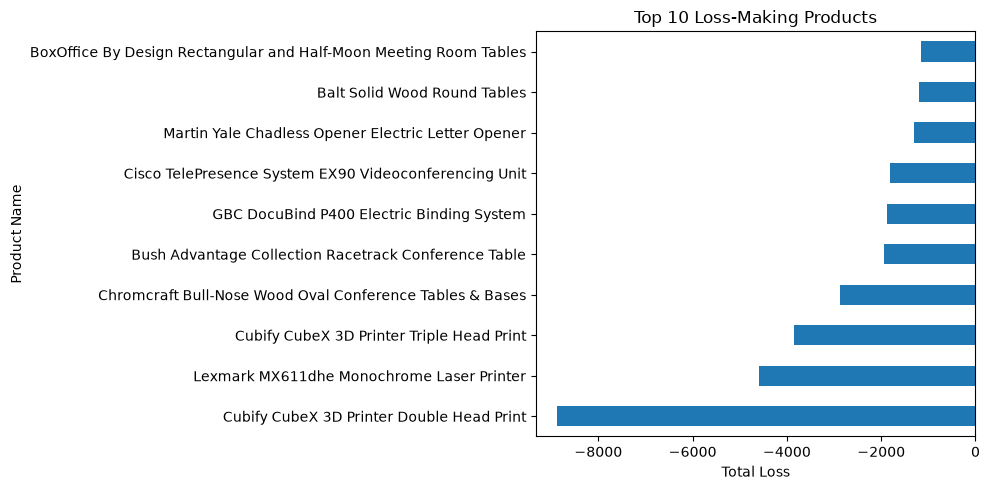

In [46]:
loss_products.plot(
    kind='barh',
    figsize=(10,5)
)

plt.title("Top 10 Loss-Making Products")
plt.xlabel("Total Loss")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

In [47]:
top_customers = (
    df.groupby('Customer Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

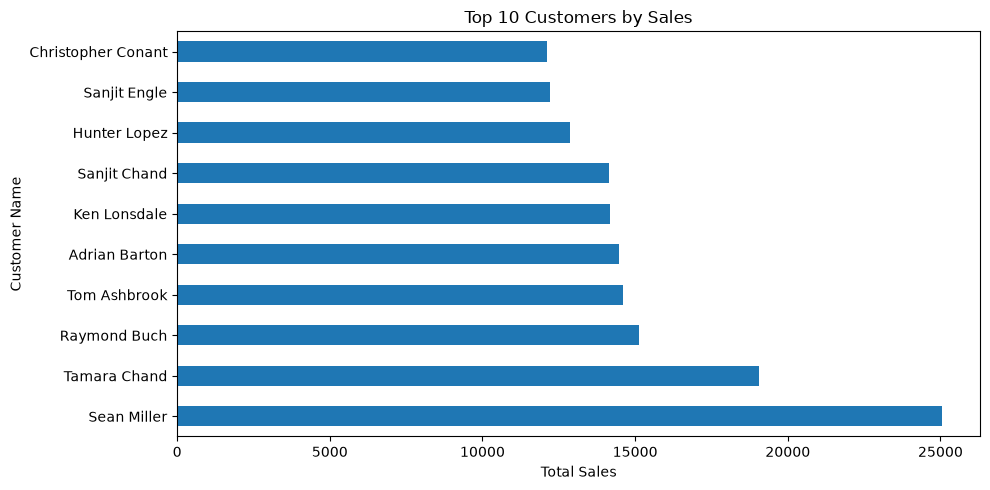

In [48]:
top_customers.plot(
    kind='barh',
    figsize=(10,5)
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer Name")
plt.tight_layout()
plt.show()

In [49]:
ship_mode_sales = df.groupby('Ship Mode')['Sales'].sum()

ship_mode_sales

Ship Mode
First Class       3.514284e+05
Same Day          1.283631e+05
Second Class      4.591936e+05
Standard Class    1.358216e+06
Name: Sales, dtype: float64

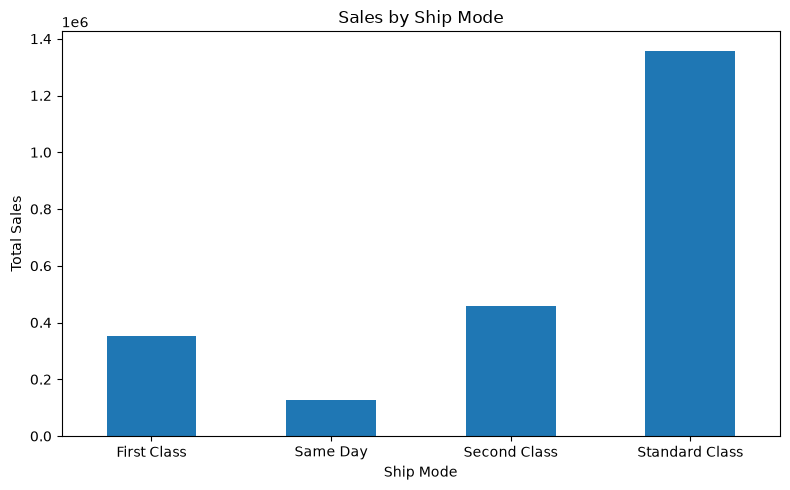

In [50]:
ship_mode_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [51]:
quantity_by_category = df.groupby('Category')['Quantity'].sum()
quantity_by_category

Category
Furniture           8028
Office Supplies    22906
Technology          6939
Name: Quantity, dtype: int64

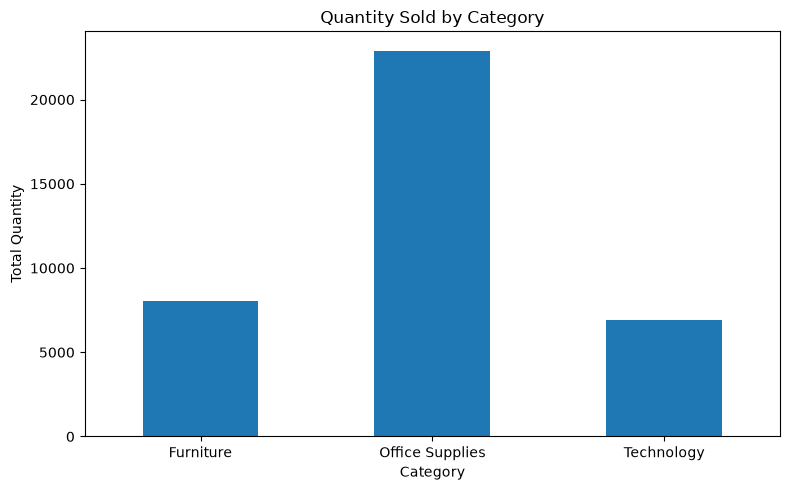

In [52]:
quantity_by_category.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Total Quantity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [53]:
sales_profit = df.groupby('Category')[['Sales', 'Profit']].sum()
sales_profit

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


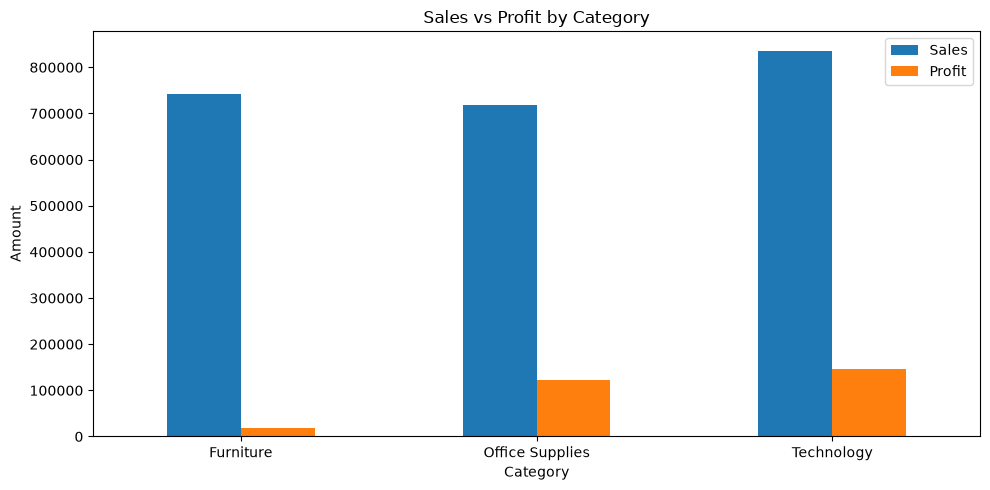

In [54]:
sales_profit.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Sales vs Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [57]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
average_order_value = total_sales / total_orders
profit_margin = (total_profit / total_sales) * 100

In [58]:
final_summary = pd.DataFrame({
    'Metric': [
        'Total Sales',
        'Total Profit',
        'Total Orders',
        'Total Customers',
        'Average Order Value',
        'Profit Margin'
    ],
    'Value': [
        total_sales,
        total_profit,
        total_orders,
        total_customers,
        average_order_value,
        profit_margin
    ]
})

final_summary

,Metric,Value
0,Total Sales,2.297201e+06
1,Total Profit,2.863970e+05
2,Total Orders,5.009000e+03
3,Total Customers,7.930000e+02
4,Average Order Value,4.586147e+02
5,Profit Margin,1.246722e+01


Business Insights

Isme hum tumhare actual results se professional insights likhenge, jaise:

Technology ki profit margin highest hai.
Furniture ki sales high hai, but profit margin bahut low hai.
Top customers ka revenue contribution.
Loss-making products.
Discount aur profitability ka relationship.